In [2]:
import pandas as pd                                                             #digital spreadsheet reader
import matplotlib.pyplot as plt                                                 #to draw graphs
import seaborn as sns                                                           #make graphs look pretty

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier                              #robot 1
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier #robot 2 & 3
from sklearn.linear_model import LogisticRegression                             #robot 4
from sklearn.metrics import accuracy_score
import joblib

In [3]:
print("Loading the dataset...")
data = pd.read_csv("adult 3.csv")

Loading the dataset...


In [4]:
data.head(10)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K
5,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K
6,29,?,227026,HS-grad,9,Never-married,?,Unmarried,Black,Male,0,0,40,United-States,<=50K
7,63,Self-emp-not-inc,104626,Prof-school,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,3103,0,32,United-States,>50K
8,24,Private,369667,Some-college,10,Never-married,Other-service,Unmarried,White,Female,0,0,40,United-States,<=50K
9,55,Private,104996,7th-8th,4,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,10,United-States,<=50K


In [5]:
data.tail(3)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
48841,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


In [6]:
data.shape

(48842, 15)

In [7]:
data.isna().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,0
relationship,0
race,0
gender,0


In [8]:
print(data.workclass.value_counts())

workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
?                    2799
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64


In [9]:
data.workclass.replace({'?': 'Others'}, inplace=True)
print(data['workclass'].value_counts())

workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
Others               2799
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64


/tmp/ipykernel_11959/1858263185.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data.workclass.replace({'?': 'Others'}, inplace=True)


In [10]:
print(data['occupation'].value_counts())

occupation
Prof-specialty       6172
Craft-repair         6112
Exec-managerial      6086
Adm-clerical         5611
Sales                5504
Other-service        4923
Machine-op-inspct    3022
?                    2809
Transport-moving     2355
Handlers-cleaners    2072
Farming-fishing      1490
Tech-support         1446
Protective-serv       983
Priv-house-serv       242
Armed-Forces           15
Name: count, dtype: int64


In [11]:
data['occupation']= data['occupation'].replace({'?':'Others'})
print(data['occupation'].value_counts())

occupation
Prof-specialty       6172
Craft-repair         6112
Exec-managerial      6086
Adm-clerical         5611
Sales                5504
Other-service        4923
Machine-op-inspct    3022
Others               2809
Transport-moving     2355
Handlers-cleaners    2072
Farming-fishing      1490
Tech-support         1446
Protective-serv       983
Priv-house-serv       242
Armed-Forces           15
Name: count, dtype: int64


In [12]:
data=data[data['workclass']!='Without-pay']
data=data[data['workclass']!='Never-worked']
print(data['workclass'].value_counts())

workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
Others               2799
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Name: count, dtype: int64


In [13]:
print(data.relationship.value_counts())


relationship
Husband           19708
Not-in-family     12582
Own-child          7566
Unmarried          5123
Wife               2327
Other-relative     1505
Name: count, dtype: int64


In [14]:
print(data.gender.value_counts())

gender
Male      32629
Female    16182
Name: count, dtype: int64


In [15]:
data.shape

(48811, 15)

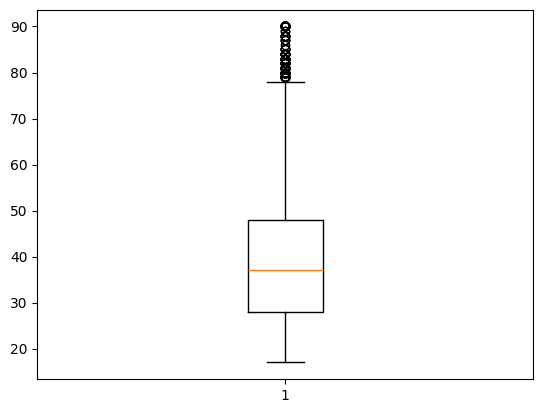

In [16]:
plt.boxplot(data['age'])
plt.show()

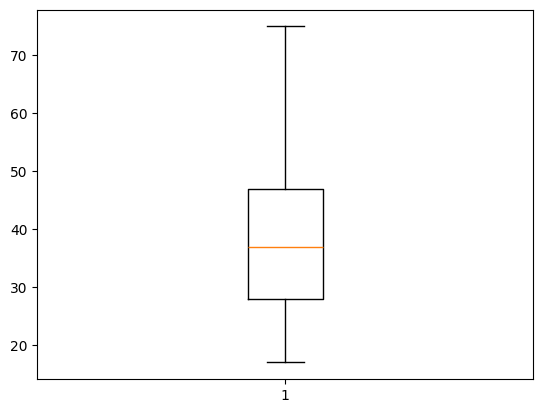

In [17]:
data=data[(data['age']<=75)&(data['age']>=17)]
plt.boxplot(data['age'])
plt.show()

In [18]:
data.shape

(48438, 15)

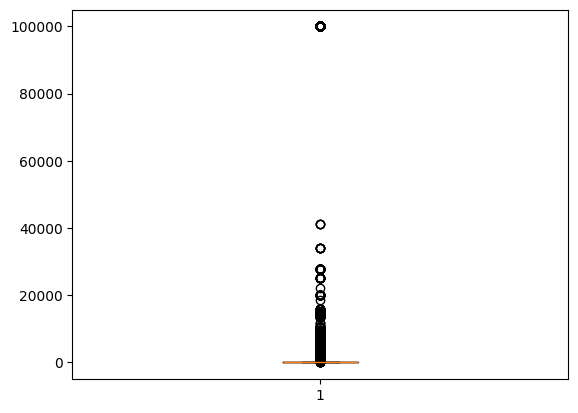

In [19]:
plt.boxplot(data['capital-gain'])
plt.show()

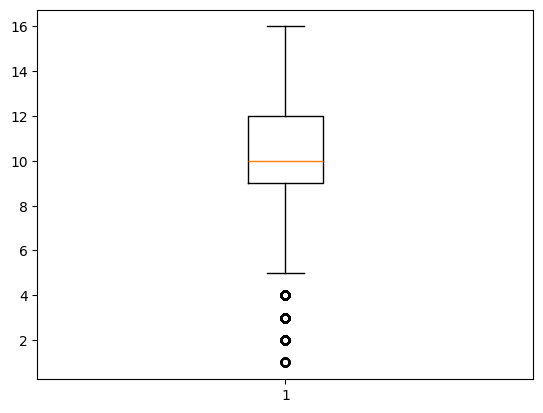

In [20]:
plt.boxplot(data['educational-num'])
plt.show()

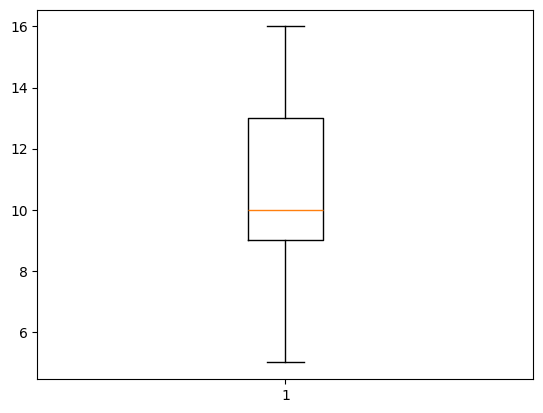

In [21]:
data=data[(data['educational-num']<=16)&(data['educational-num']>=5)]
plt.boxplot(data['educational-num'])
plt.show()

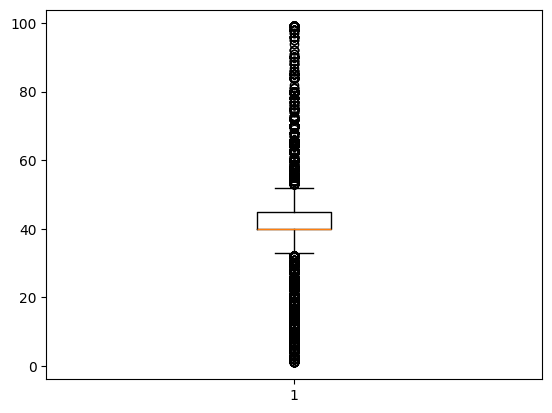

In [22]:
plt.boxplot(data['hours-per-week'])
plt.show()

In [23]:
data.shape

(46720, 15)

In [24]:
data

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,Others,103497,Some-college,10,Never-married,Others,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [25]:
data

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,Others,103497,Some-college,10,Never-married,Others,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [26]:
from sklearn.preprocessing import LabelEncoder   #import libarary
encoder=LabelEncoder()                       #create object
data['workclass']=encoder.fit_transform(data['workclass']) #7 categories   0,1, 2, 3, 4, 5, 6,
data['marital-status']=encoder.fit_transform(data['marital-status'])   #3 categories 0, 1, 2
data['occupation']=encoder.fit_transform(data['occupation'])
data['relationship']=encoder.fit_transform(data['relationship'])      #5 categories  0, 1, 2, 3, 4
data['race']=encoder.fit_transform(data['race'])
data['gender']=encoder.fit_transform(data['gender'])    #2 catogories     0, 1
data['native-country']=encoder.fit_transform(data['native-country'])

In [27]:
data

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,3,226802,11th,7,4,6,3,2,1,0,0,40,39,<=50K
1,38,3,89814,HS-grad,9,2,4,0,4,1,0,0,50,39,<=50K
2,28,1,336951,Assoc-acdm,12,2,11,0,4,1,0,0,40,39,>50K
3,44,3,160323,Some-college,10,2,6,0,2,1,7688,0,40,39,>50K
4,18,2,103497,Some-college,10,4,8,3,4,0,0,0,30,39,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,3,257302,Assoc-acdm,12,2,13,5,4,0,0,0,38,39,<=50K
48838,40,3,154374,HS-grad,9,2,6,0,4,1,0,0,40,39,>50K
48839,58,3,151910,HS-grad,9,6,0,4,4,0,0,0,40,39,<=50K
48840,22,3,201490,HS-grad,9,4,0,3,4,1,0,0,20,39,<=50K


In [28]:
x = data[['age',
          'education',
          'occupation',
          'hours-per-week']]
y=data['income']
x

,age,education,occupation,hours-per-week
0,25,11th,6,40
1,38,HS-grad,4,50
2,28,Assoc-acdm,11,40
3,44,Some-college,6,40
4,18,Some-college,8,30
...,...,...,...,...
48837,27,Assoc-acdm,13,38
48838,40,HS-grad,6,40
48839,58,HS-grad,0,40
48840,22,HS-grad,0,20


In [33]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import joblib

# Reload original dataset
data_original = pd.read_csv("adult 3.csv")

education_encoder = LabelEncoder()
occupation_encoder = LabelEncoder()

education_encoder.fit(data_original['education'])
occupation_encoder.fit(data_original['occupation'])

joblib.dump(education_encoder, "education_encoder.pkl")
joblib.dump(occupation_encoder, "occupation_encoder.pkl")

print(occupation_encoder.classes_)

['?' 'Adm-clerical' 'Armed-Forces' 'Craft-repair' 'Exec-managerial'
 'Farming-fishing' 'Handlers-cleaners' 'Machine-op-inspct' 'Other-service'
 'Priv-house-serv' 'Prof-specialty' 'Protective-serv' 'Sales'
 'Tech-support' 'Transport-moving']


In [35]:
print(x.head())
print(x.dtypes)

   age     education  occupation  hours-per-week
0   25          11th           6              40
1   38       HS-grad           4              50
2   28    Assoc-acdm          11              40
3   44  Some-college           6              40
4   18  Some-college           8              30
age                int64
education         object
occupation         int64
hours-per-week     int64
dtype: object


In [36]:
from sklearn.preprocessing import LabelEncoder

education_encoder = LabelEncoder()

x['education'] = education_encoder.fit_transform(x['education'])

/tmp/ipykernel_11959/3972166814.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x['education'] = education_encoder.fit_transform(x['education'])


In [37]:
print(x.dtypes)

age               int64
education         int64
occupation        int64
hours-per-week    int64
dtype: object


In [38]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, OneHotEncoder

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

models = {
    "LogisticRegression": LogisticRegression(),
    "RandomForest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "GradientBoosting": GradientBoostingClassifier()
}

results = {}

for name, model in models.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))


LogisticRegression Accuracy: 0.7457
              precision    recall  f1-score   support

       <=50K       0.77      0.95      0.85      7010
        >50K       0.47      0.13      0.20      2334

    accuracy                           0.75      9344
   macro avg       0.62      0.54      0.53      9344
weighted avg       0.69      0.75      0.69      9344

RandomForest Accuracy: 0.7669
              precision    recall  f1-score   support

       <=50K       0.82      0.88      0.85      7010
        >50K       0.54      0.41      0.47      2334

    accuracy                           0.77      9344
   macro avg       0.68      0.65      0.66      9344
weighted avg       0.75      0.77      0.76      9344

KNN Accuracy: 0.7621
              precision    recall  f1-score   support

       <=50K       0.82      0.87      0.85      7010
        >50K       0.53      0.43      0.47      2334

    accuracy                           0.76      9344
   macro avg       0.68      0.65      0.

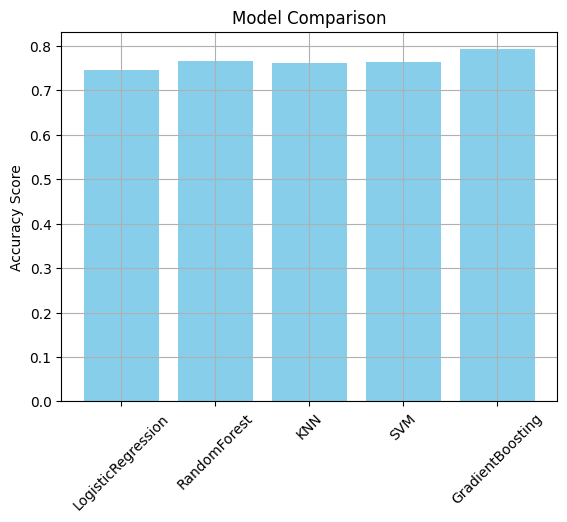

In [39]:
import matplotlib.pyplot as plt
plt.bar(results.keys(), results.values(), color='skyblue')
plt.ylabel('Accuracy Score')
plt.title('Model Comparison')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import joblib

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Define models
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "GradientBoosting": GradientBoostingClassifier()
}

results = {}

# Train and evaluate
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"{name}: {acc:.4f}")

# Get best model
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]
print(f"\n✅ Best model: {best_model_name} with accuracy {results[best_model_name]:.4f}")

# Save the best model
joblib.dump(best_model, "best_model.pkl")
print("✅ Saved best model as best_model.pkl")

LogisticRegression: 0.7457
RandomForest: 0.7670
KNN: 0.7613
SVM: 0.7556
GradientBoosting: 0.7922

✅ Best model: GradientBoosting with accuracy 0.7922
✅ Saved best model as best_model.pkl


In [41]:
import joblib

joblib.dump(best_model, "best_model.pkl")
joblib.dump(education_encoder, "education_encoder.pkl")
joblib.dump(occupation_encoder, "occupation_encoder.pkl")

['occupation_encoder.pkl']

In [42]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib

# Load the trained model
model = joblib.load("best_model.pkl")
education_encoder = joblib.load("education_encoder.pkl")
occupation_encoder = joblib.load("occupation_encoder.pkl")

st.set_page_config(page_title="Employee Salary Classification", page_icon="💼", layout="centered")

st.title("💼 Employee Salary Classification App")
st.markdown("Predict whether an employee earns >50K or ≤50K based on input features.")

# Sidebar inputs (these must match your training feature columns)
st.sidebar.header("Input Employee Details")

# ✨ Replace these fields with your dataset's actual input columns
age = st.sidebar.slider("Age", 18, 65, 30)
education = st.sidebar.selectbox("Education Level", [
    "Bachelors", "Masters", "PhD", "HS-grad", "Assoc", "Some-college"
])
occupation = st.sidebar.selectbox("Job Role", [
    "Tech-support", "Craft-repair", "Other-service", "Sales",
    "Exec-managerial", "Prof-specialty", "Handlers-cleaners", "Machine-op-inspct",
    "Adm-clerical", "Farming-fishing", "Transport-moving", "Priv-house-serv",
    "Protective-serv", "Armed-Forces"
])
hours_per_week = st.sidebar.slider("Hours per week", 1, 80, 40)
education_encoded = education_encoder.transform([education])[0]
occupation_encoded = occupation_encoder.transform([occupation])[0]
# Build input DataFrame (⚠️ must match preprocessing of your training data)
input_df = pd.DataFrame({
    'age': [age],
    'education': [education_encoded],
    'occupation': [occupation_encoded],
    'hours-per-week': [hours_per_week]
})

st.write("### 🔎 Input Data")
st.write(input_df)

# Predict button
if st.button("Predict Salary Class"):
    st.write("Model expects:", model.feature_names_in_)
    st.write("Input columns:", input_df.columns.tolist())
    prediction = model.predict(input_df)
    st.success(f"✅ Prediction: {prediction[0]}")

# Batch prediction
st.markdown("---")
st.markdown("#### 📂 Batch Prediction")
uploaded_file = st.file_uploader("Upload a CSV file for batch prediction", type="csv")

if uploaded_file is not None:
    batch_data = pd.read_csv(uploaded_file)
    st.write("Uploaded data preview:", batch_data.head())
    batch_preds = model.predict(batch_data)
    batch_data['PredictedClass'] = batch_preds
    st.write("✅ Predictions:")
    st.write(batch_data.head())
    csv = batch_data.to_csv(index=False).encode('utf-8')
    st.download_button("Download Predictions CSV", csv, file_name='predicted_classes.csv', mime='text/csv')



Writing app.py


In [43]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 93.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 93.2 MB/s eta 0:00:00


In [44]:
!ls

'adult 3.csv'   best_model.pkl	        occupation_encoder.pkl
 app.py         education_encoder.pkl   sample_data


In [45]:
!streamlit run app.py &



2026-06-10 20:24:29.661 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.142.201.69:8501

  Stopping...


In [46]:
!python app.py

2026-06-10 20:25:31.182 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-10 20:25:31.183 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-10 20:25:31.709 
  command:

    streamlit run app.py [ARGUMENTS]
2026-06-10 20:25:31.709 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-10 20:25:31.709 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-10 20:25:31.710 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-10 20:25:31.710 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-10 20:25:31.710 Thread 'MainThre

In [47]:
print(occupation_encoder.classes_)

['?' 'Adm-clerical' 'Armed-Forces' 'Craft-repair' 'Exec-managerial'
 'Farming-fishing' 'Handlers-cleaners' 'Machine-op-inspct' 'Other-service'
 'Priv-house-serv' 'Prof-specialty' 'Protective-serv' 'Sales'
 'Tech-support' 'Transport-moving']


In [48]:
import joblib

joblib.dump(occupation_encoder, "occupation_encoder.pkl")
joblib.dump(education_encoder, "education_encoder.pkl")

['education_encoder.pkl']

In [49]:
joblib.dump(best_model, "best_model.pkl")

['best_model.pkl']

In [50]:
!streamlit run app.py &



2026-06-10 20:27:43.112 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.142.201.69:8501

  Stopping...
